<a href="https://colab.research.google.com/github/AM-kitsune/PCVK_Ganjil_2026/blob/main/Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from google.colab.patches import cv2_imshow

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
folder = '/content/drive/MyDrive/ColabNotebooks/'

Mengubah tingkat kecerahan citra
-----------------------------------
Masukkan nilai kecerahan: 40


/tmp/ipykernel_1592/357957003.py:14: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)


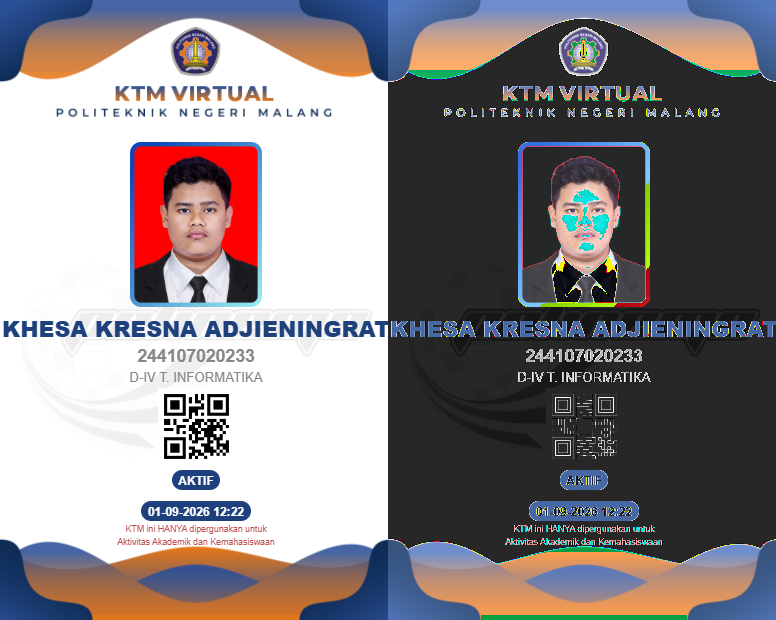

In [13]:
print('Mengubah tingkat kecerahan citra')
print('-----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, bukan angka')

original = cv.imread(folder + 'KTM.png')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

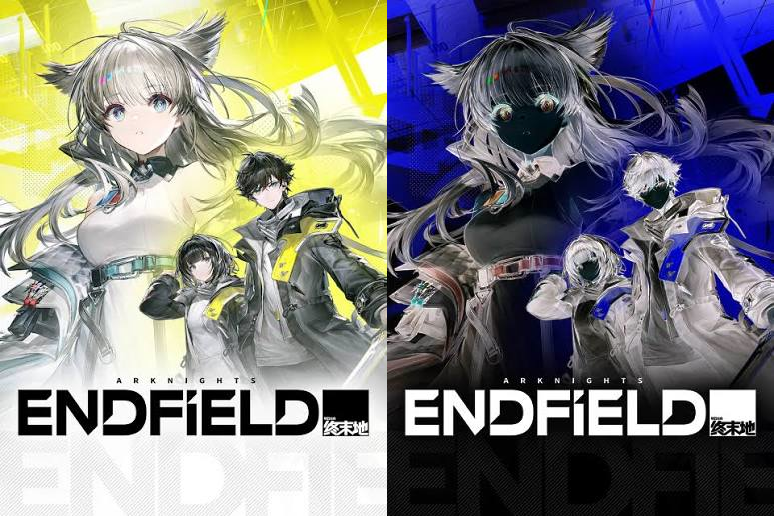

In [11]:
original = cv.imread(folder + 'ksks.jpg')
inverse_image = 255 - original

final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

Mengubah kontras dan tingkat kecerahan citra
-----------------------------------------------
Masukkan tingkat kecerahan : 20
Masukkan kontras : 40


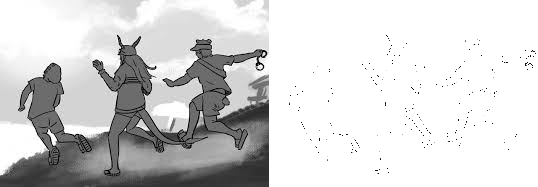

In [15]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('-----------------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, bukan angka')

original = cv.imread(folder + 'images.jpeg')
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            contrast_image[y, x, c] = np.clip(contrast * original[y, x, c] + brightness, 0, 255)

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

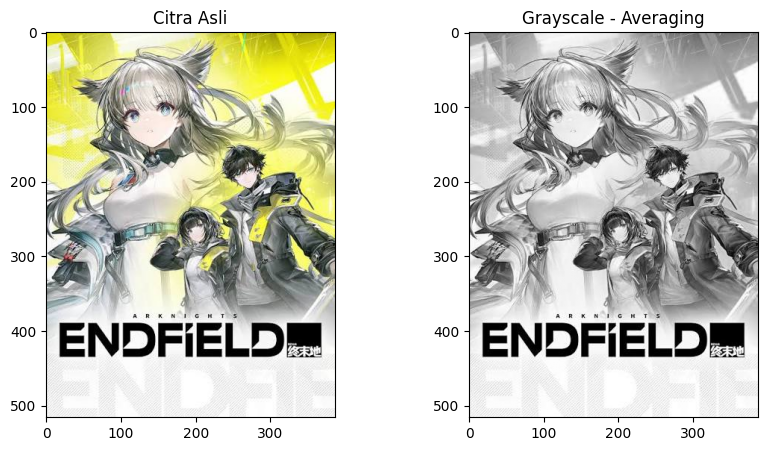

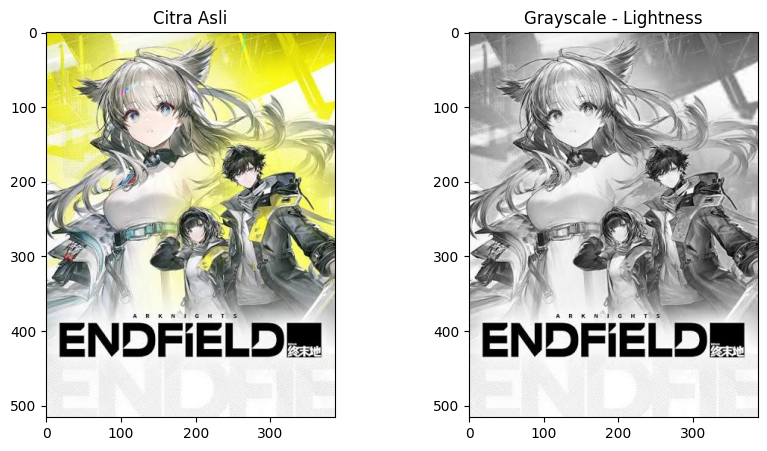

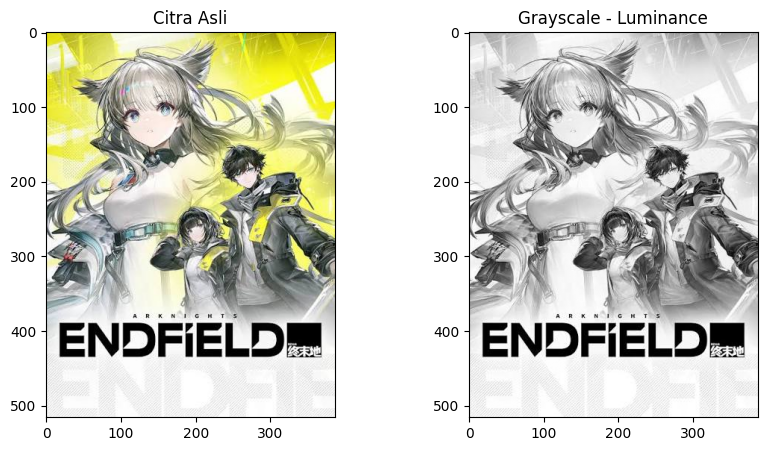

In [28]:
img = cv.imread(folder + 'ksks.jpg')

if img is None:
    print('Gagal membaca file. Cek kembali nama file dan path folder:', folder + 'ksks.jpg')
else:
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB).astype(np.float64)

    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]

    # a. Averaging
    gray_avg = ((R + G + B) / 3).astype(np.uint8)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_rgb.astype(np.uint8)); ax[0].set_title('Citra Asli')
    ax[1].imshow(gray_avg, cmap='gray'); ax[1].set_title('Grayscale - Averaging')
    plt.show()

    # b. Lightness
    gray_lightness = ((np.max(img_rgb, axis=2) + np.min(img_rgb, axis=2)) / 2).astype(np.uint8)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_rgb.astype(np.uint8)); ax[0].set_title('Citra Asli')
    ax[1].imshow(gray_lightness, cmap='gray'); ax[1].set_title('Grayscale - Lightness')
    plt.show()

    # c. Luminance
    gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_rgb.astype(np.uint8)); ax[0].set_title('Citra Asli')
    ax[1].imshow(gray_luminance, cmap='gray'); ax[1].set_title('Grayscale - Luminance')
    plt.show()

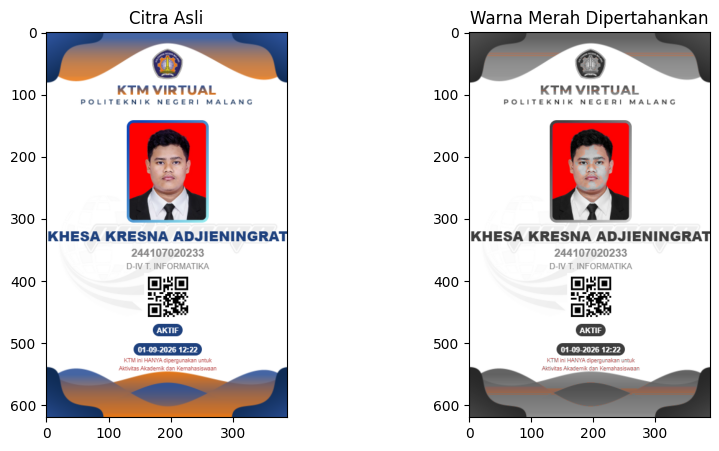

In [29]:
img = cv.imread(folder + 'KTM.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

lower_red1 = np.array([0, 70, 50]);   upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 70, 50]); upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
mask_red = cv.bitwise_or(mask1, mask2)

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

result = np.where(mask_red[:, :, None] == 255, img, gray_bgr)
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_rgb); ax[0].set_title('Citra Asli')
ax[1].imshow(result_rgb); ax[1].set_title('Warna Merah Dipertahankan')
plt.show()

Gamma Correction pada citra
----------------------------------
Masukkan nilai Gamma: 10


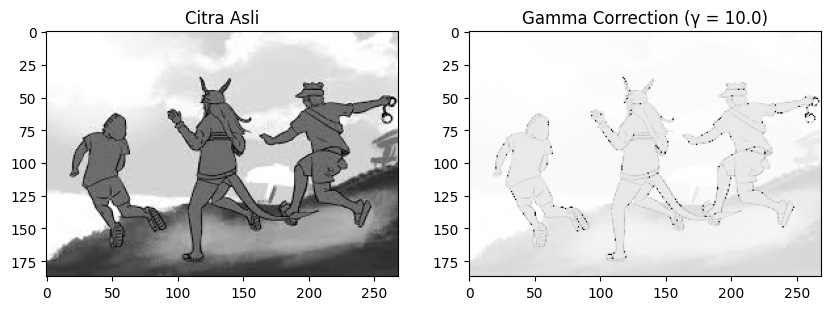

In [32]:
print('Gamma Correction pada citra')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, bukan angka')

original = cv.imread(folder + 'images.jpeg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

gamma_image = 255 * (original_rgb / 255) ** (1 / gamma)
gamma_image = np.clip(gamma_image, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_rgb); ax[0].set_title('Citra Asli')
ax[1].imshow(gamma_image); ax[1].set_title(f'Gamma Correction (γ = {gamma})')
plt.show()

Simulasi Image Depth (Kuantisasi Citra)
-------------------------------------------
Masukkan bit depth tujuan (1-8): 1
Bit depth awal  : 8 bit
Bit depth tujuan: 1 bit
Jumlah level    : 2


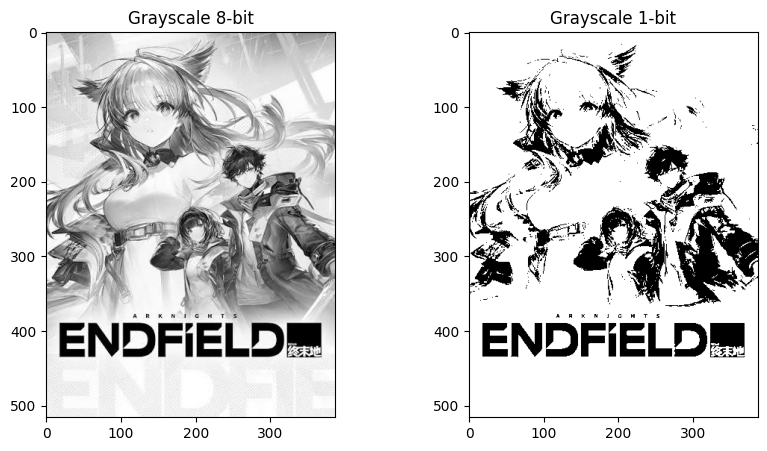

In [31]:
print('Simulasi Image Depth (Kuantisasi Citra)')
print('-------------------------------------------')
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, bukan angka')

level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread(folder + 'ksks.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        depth_image[y, x] = round(original[y, x] / level) * level

print('Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level    : {pow(2, bit_depth)}')

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original, cmap='gray'); ax[0].set_title('Grayscale 8-bit')
ax[1].imshow(depth_image, cmap='gray'); ax[1].set_title(f'Grayscale {bit_depth}-bit')
plt.show()

Jumlah citra: 10 | PSNR: 29.51 dB


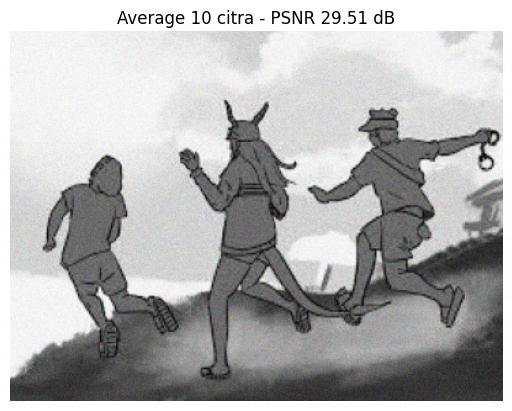

Jumlah citra: 20 | PSNR: 31.36 dB


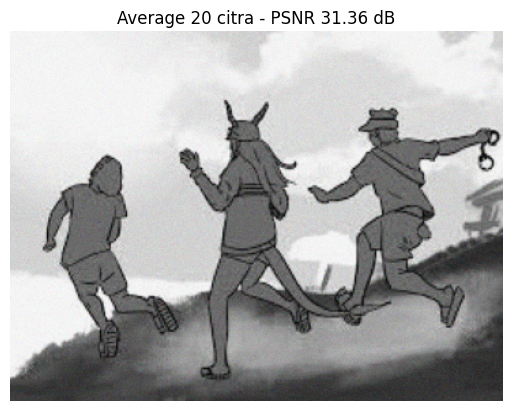

Jumlah citra: 40 | PSNR: 32.71 dB


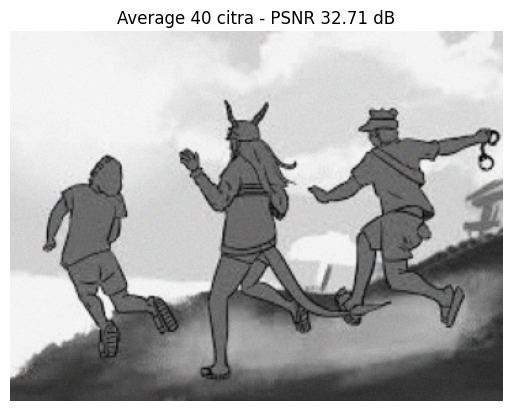

Jumlah citra: 80 | PSNR: 33.58 dB


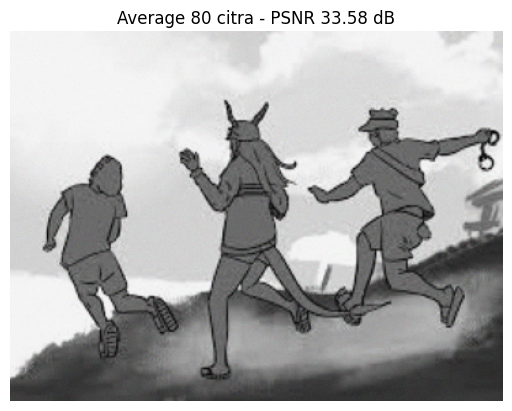

Jumlah citra: 100 | PSNR: 33.78 dB


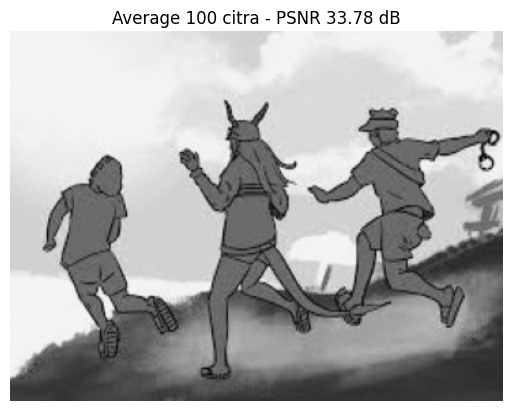

In [33]:
def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

# Citra asli
original = cv.imread(folder + 'images.jpeg')
original = cv.resize(original, (400, 300))

# Membuat 100 citra dengan Gaussian noise secara acak
np.random.seed(42)
noisy_images = []
for i in range(100):
    noise = np.random.normal(0, 25, original.shape)
    noisy = np.clip(original.astype(np.float64) + noise, 0, 255).astype(np.uint8)
    noisy_images.append(noisy)

jumlah_citra_list = [10, 20, 40, 80, 100]

for jumlah in jumlah_citra_list:
    avg_image = np.zeros(original.shape, dtype=np.float64)
    for i in range(jumlah):
        avg_image += noisy_images[i].astype(np.float64)
    avg_image = (avg_image / jumlah).astype(np.uint8)

    psnr_value = PSNR(original, avg_image)
    print(f'Jumlah citra: {jumlah} | PSNR: {psnr_value:.2f} dB')

    avg_rgb = cv.cvtColor(avg_image, cv.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(avg_rgb)
    plt.title(f'Average {jumlah} citra - PSNR {psnr_value:.2f} dB')
    plt.axis('off')
    plt.show()

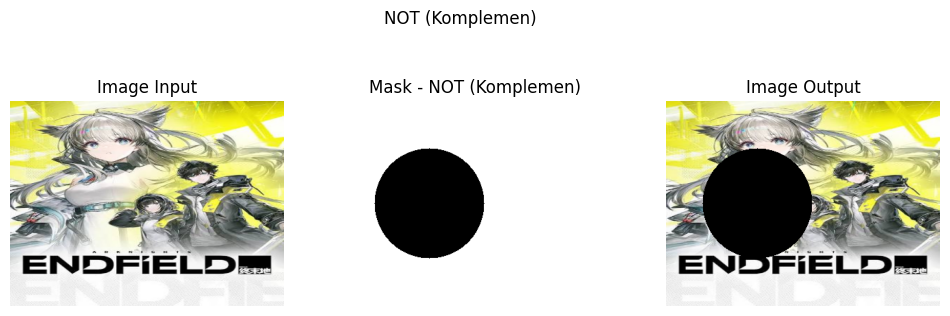

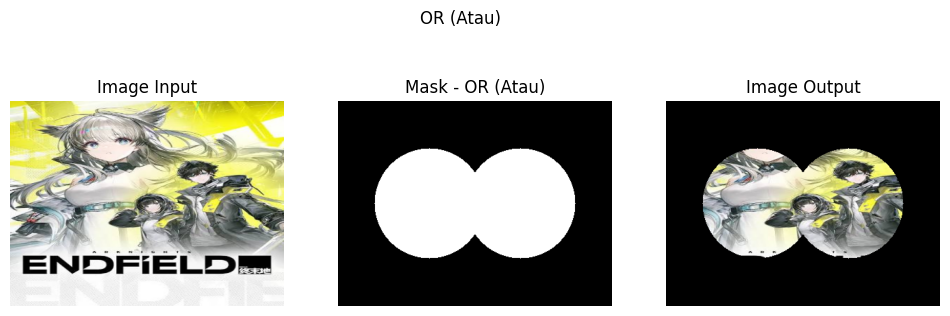

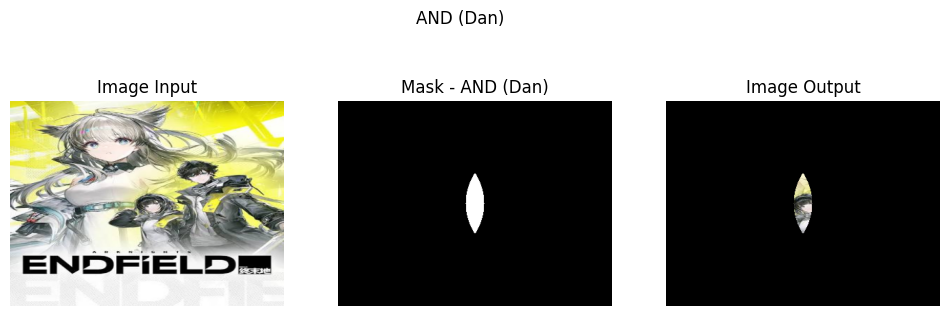

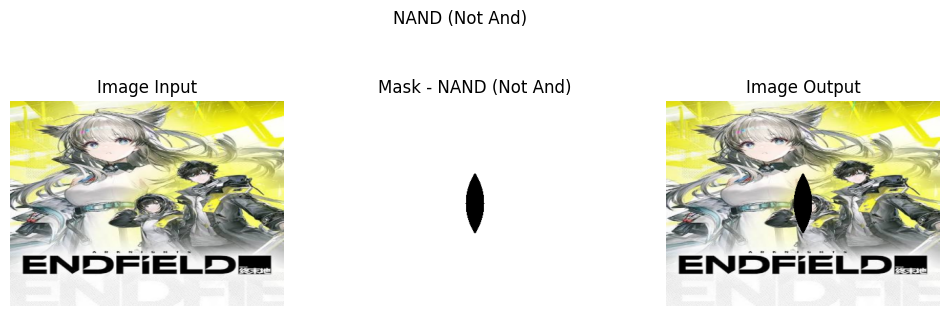

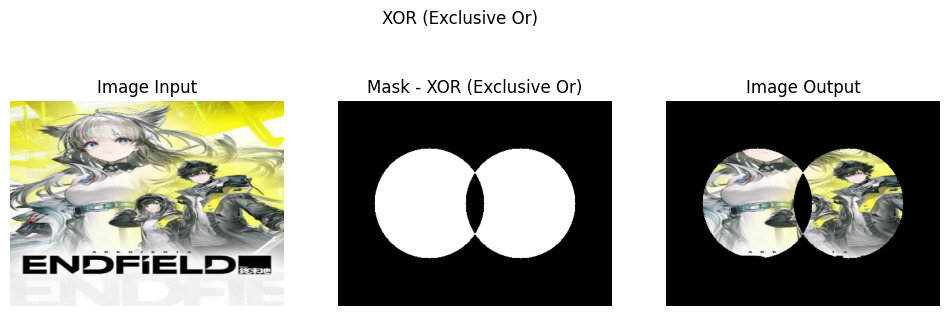

In [37]:
img = cv.imread(folder + 'ksks.jpg')
img = cv.resize(img, (400, 300))
h, w = img.shape[:2]

mask_A = np.zeros((h, w), dtype=np.uint8)
cv.circle(mask_A, (w // 3, h // 2), 80, 255, -1)

mask_B = np.zeros((h, w), dtype=np.uint8)
cv.circle(mask_B, (2 * w // 3, h // 2), 80, 255, -1)

not_result  = cv.bitwise_not(mask_A)
or_result   = cv.bitwise_or(mask_A, mask_B)
and_result  = cv.bitwise_and(mask_A, mask_B)
nand_result = cv.bitwise_not(and_result)
xor_result  = cv.bitwise_xor(mask_A, mask_B)

operators = {
    'NOT (Komplemen)': not_result,
    'OR (Atau)': or_result,
    'AND (Dan)': and_result,
    'NAND (Not And)': nand_result,
    'XOR (Exclusive Or)': xor_result,
}

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

for nama, mask in operators.items():
    hasil = cv.bitwise_and(img, img, mask=mask)
    hasil_rgb = cv.cvtColor(hasil, cv.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(img_rgb); ax[0].set_title('Image Input')
    ax[1].imshow(mask, cmap='gray'); ax[1].set_title(f'Mask - {nama}')
    ax[2].imshow(hasil_rgb); ax[2].set_title('Image Output')
    for a in ax:
        a.axis('off')
    plt.suptitle(nama)
    plt.show()

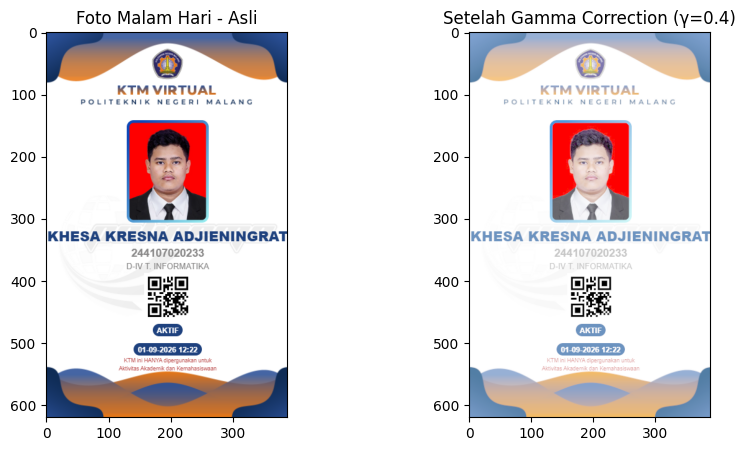

In [38]:
night_img = cv.imread(folder + 'KTM.png')
night_rgb = cv.cvtColor(night_img, cv.COLOR_BGR2RGB)

gamma = 0.4
enhanced = 255 * (night_rgb / 255) ** gamma
enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(night_rgb); ax[0].set_title('Foto Malam Hari - Asli')
ax[1].imshow(enhanced); ax[1].set_title(f'Setelah Gamma Correction (γ={gamma})')
plt.show()

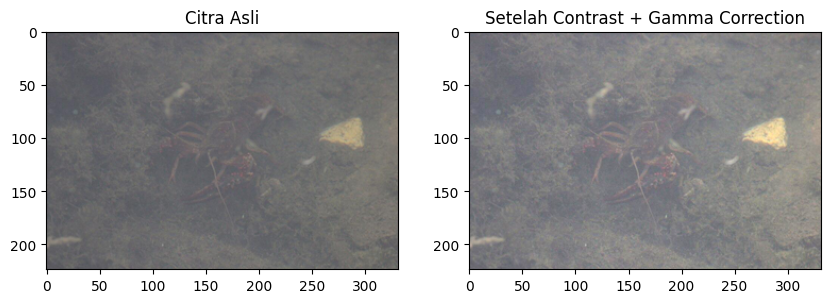

In [40]:
img = cv.imread(folder + 'fih.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB).astype(np.float64)

contrast = 1.3
brightness = 10
contrast_img = np.clip(contrast * img_rgb + brightness, 0, 255)

gamma = 0.8
final_img = 255 * (contrast_img / 255) ** (1 / gamma)
final_img = np.clip(final_img, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_rgb.astype(np.uint8)); ax[0].set_title('Citra Asli')
ax[1].imshow(final_img); ax[1].set_title('Setelah Contrast + Gamma Correction')
plt.show()

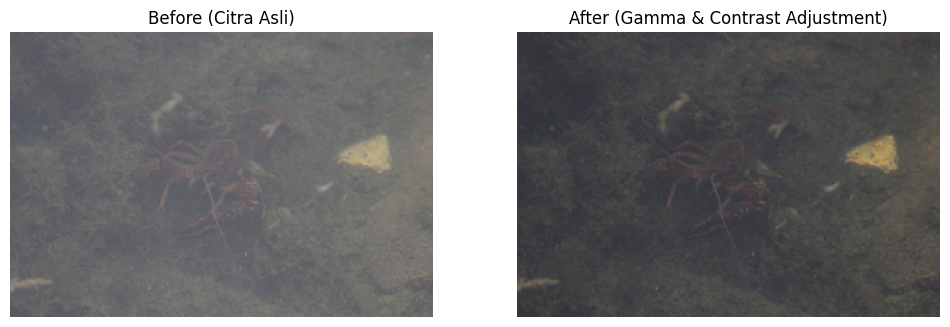

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/ColabNotebooks/fih.png'

img_bgr = cv2.imread(path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

gamma = 0.5
inv_gamma = 1.0 / gamma
table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
gamma_img = cv2.LUT(img_rgb, table)
alpha = 1.2
beta = 15
enhanced_img = cv2.convertScaleAbs(gamma_img, alpha=alpha, beta=beta)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Before (Citra Asli)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_img)
plt.title('After (Gamma & Contrast Adjustment)')
plt.axis('off')

plt.show()